# Experiment Management: Actionability LLM Judge

Imagine your team uses an LLM to draft code review comments for pull requests. The comments should help developers improve the code, but generated feedback can easily become vague, overly positive, too harsh, or too abstract.

To make this workflow reliable, we will build an **Actionability** LLM judge. The judge will decide whether a generated PR review is useful enough to show to a developer.

We will not define the final judge upfront. Instead, we will treat this as an experiment loop:

1. write the simplest judge prompt,
2. measure it against expert labels,
3. inspect disagreements using expert comments,
4. form a better prompt hypothesis,
5. repeat.

Along the way, we will keep a clean pandas experiment log with judge version, description, provider, model, and metrics.

## 1. Dataset

The dataset contains generated PR review comments, expert labels, and expert comments. We will treat the expert label as the reference answer and the expert comment as human feedback for improving the judge.

In [1]:
# Import libraries
import json
import re
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

In [2]:
# Load human-reviewed examples
DATA_PATH = Path("data/code_review.csv")

df = pd.read_csv(DATA_PATH)

df = df.rename(columns={
    "Generated review": "review",
    "Expert label": "expert_label",
    "Expert comment": "expert_comment",
})

df["id"] = np.arange(1, len(df) + 1)
df["expert_label"] = df["expert_label"].str.strip().str.lower()
df["expert_comment"] = df["expert_comment"].fillna("")

df = df[["id", "review", "expert_label", "expert_comment"]]

print(f"Total examples: {len(df)}")
df.head()

Total examples: 50


,id,review,expert_label,expert_comment
0,1,"This implementation appears to work, but the a...",bad,"The tone is slighly condescending, no actionab..."
1,2,Great job! Keep it up!,bad,Not actionable
2,3,It would be advisable to think about modularit...,bad,"there is a suggestion, but no real guidance"
3,4,"You’ve structured the class very well, and the...",good,"Good tone, actionable"
4,5,Great job! This is clean and well-organized. T...,bad,Pure praise


In [3]:
label_summary = (
    df["expert_label"]
    .value_counts()
    .rename_axis("expert_label")
    .reset_index(name="count")
)

label_summary["share_%"] = (
    label_summary["count"] / label_summary["count"].sum() * 100
).round(1)

label_summary

,expert_label,count,share_%
0,bad,27,54.0
1,good,23,46.0


## 2. Development and Test Split

We will use the development set to improve the judge prompt. The test set stays untouched until the end.

The dataset is small, so these metrics are useful for learning and comparison, not for claiming production readiness.

In [4]:
dev_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["expert_label"],
)

dev_df = dev_df.sort_values("id").reset_index(drop=True)
test_df = test_df.sort_values("id").reset_index(drop=True)

print(f"Development examples: {len(dev_df)}")
print(f"Test examples: {len(test_df)}")

Development examples: 35
Test examples: 15


## 3. Experiment Harness

Before writing any judge prompts, we set up the experiment harness.

The important design choice: `experiment_runs` has one row per judge run. Detailed predictions stay in `prediction_tables`, so the experiment log remains clean and easy to compare.

In [5]:
RUN_LIVE_LLM = True

LIVE_PROVIDER = "openai"
LIVE_MODEL = "gpt-5.5"  # Change this if you want to run another judge model.

DEMO_PROVIDER = "demo"
DEMO_MODEL = "rule-based-demo"

PROVIDER = LIVE_PROVIDER if RUN_LIVE_LLM else DEMO_PROVIDER
MODEL = LIVE_MODEL if RUN_LIVE_LLM else DEMO_MODEL

LABELS = ["bad", "good"]
JUDGE_CONFIGS = {}

print(f"Provider: {PROVIDER}")
print(f"Model: {MODEL}")

Provider: openai
Model: gpt-5.5


In [6]:
def register_judge(judge_version, short_description, criteria):
    JUDGE_CONFIGS[judge_version] = {
        "short_description": short_description,
        "criteria": criteria.strip(),
    }


def build_judge_messages(review, criteria):
    system_message = f"""
You are an expert evaluator for generated code review feedback.

Use the criteria below to judge whether the review is actionable.

Criteria:
{criteria}

Return JSON only with this schema:
{{
  "predicted_label": "good" or "bad",
  "reason": "short explanation"
}}
""".strip()

    user_message = f"""
Generated PR review:
{review}
""".strip()

    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_message},
    ]


def parse_judge_json(content):
    try:
        result = json.loads(content)
    except json.JSONDecodeError:
        return {
            "predicted_label": "bad",
            "reason": "Judge returned invalid JSON, so this output is treated as bad.",
        }

    label = str(result.get("predicted_label", "bad")).strip().lower()
    if label not in LABELS:
        label = "bad"

    return {
        "predicted_label": label,
        "reason": str(result.get("reason", "")).strip(),
    }


def judge_with_openai(review, config, model):
    # This function is only used when RUN_LIVE_LLM = True.
    from openai import OpenAI

    client = OpenAI()
    messages = build_judge_messages(review, config["criteria"])

    response = client.chat.completions.create(
        model=model,
        messages=messages,
        response_format={"type": "json_object"},
    )

    content = response.choices[0].message.content
    return parse_judge_json(content)

In [7]:
def merge_unique(*lists):
    values = []
    seen = set()

    for items in lists:
        for item in items:
            if item not in seen:
                values.append(item)
                seen.add(item)

    return values


NAIVE_SUGGESTION_CUES = [
    "suggest", "consider", "could", "might", "improve", "improvement",
    "refactor", "add", "extract", "simplify", "rename", "document",
    "cache", "log", "check", "test",
]

PRAISE_OR_FILLER_PATTERNS = [
    "great job!", "keep it up", "nothing to improve", "no changes needed",
    "excellent submission overall", "you did a great job here", "really nice work",
    "overall, great work",
]

VAGUE_FEEDBACK_PATTERNS = [
    "some improvements", "certain improvements", "refactoring possibilities",
    "potential opportunity", "more modern way", "stylistic adjustments",
    "idiomatic way", "reviewing the loop conditions", "be mindful",
    "more readable terms", "revise?",
]

BASIC_REJECTION_PATTERNS = merge_unique(
    PRAISE_OR_FILLER_PATTERNS,
    VAGUE_FEEDBACK_PATTERNS,
)

CONCRETE_ACTION_CUES = [
    "add", "extract", "break", "split", "create", "centralize",
    "document", "cache", "log", "double-check", "fallback", "move",
    "rename", "using array methods", "map", "filter", "foreach",
    "constant", "utility", "comment", "test",
]

CORE_CODE_TARGETS = [
    "null", "undefined", "empty", "500", "constructor", "helper",
    "method", "function", "ttl", "loop", "processdata", "handler",
    "config", "options", "timeout", "pagination", "pagesize",
    "headers", "retry", "fallback", "error handler", "input array",
    "validation",
]

FAILURE_MODE_PATTERNS = merge_unique(
    [
        "great job! keep it up", "i can review the code", "in this function,",
        "idiomatic standards", "cross-functional scenarios", "depending on your team",
        "nonstandard", "possibly worth reviewing", "not sure if this matters",
        "just flagging", "slightly unconventional", "maybe simplify it a bit",
        "larger datasets", "could be optimized", "benefit from certain improvements",
        "explore refactoring", "consider refactoring this step",
        "be mindful of potential issues", "several issues around control flow",
        "quite a bit of duplication",
    ],
    BASIC_REJECTION_PATTERNS,
)

EXTENDED_CODE_TARGETS = merge_unique(
    CORE_CODE_TARGETS,
    [
        "state", "immutability", "for loop", "foreach", "array methods",
        "map", "filter", "constant", "dependency injection", "hardcoded",
    ],
)

ACTION_VERB_CUES = [
    "add", "extract", "break", "split", "create", "centralize",
    "document", "cache", "log", "double-check", "move", "rename",
    "refactor", "covering", "grouping", "using", "introducing",
    "simplify", "check", "handled",
]

CONSTRUCTIVE_TONE_CUES = [
    "could", "might", "consider", "possible improvement", "one idea",
    "one thing", "minor note", "to make", "would improve",
    "would help", "that could", "that might",
]

HARSH_TONE_CUES = [
    "too much complexity", "can lead to bugs", "should be split",
    "quite messy", "hard to follow",
]

CALIBRATED_FAILURE_PATTERNS = merge_unique(
    FAILURE_MODE_PATTERNS,
    ["too much complexity"],
)

CALIBRATED_CODE_TARGETS = merge_unique(
    EXTENDED_CODE_TARGETS,
    [
        "warning", "observability", "debugging", "inline comment",
        "special-case condition", "unexpected input shapes",
    ],
)

REPETITIVE_PRAISE_RE = re.compile(r"great job!?\s+one thing.*great job again")

In [8]:
#judge simulation for non-llm scenario

def _contains_any(text, patterns):
    return any(pattern in text for pattern in patterns)


def judge_with_demo_rules(review, judge_version):
    """Deterministic stand-in for the tutorial.

    The live LLM path uses the criteria prompts. The demo path lets the notebook run
    without credentials while still showing the experiment-management workflow.
    """
    text = review.lower()

    if judge_version == "v0_naive":
        is_good = len(review.split()) >= 18 and _contains_any(text, NAIVE_SUGGESTION_CUES)
        reason = "Naive rule: long enough and contains a suggestion cue." if is_good else "Naive rule: too short or no suggestion cue."
        return {"predicted_label": "good" if is_good else "bad", "reason": reason}

    if judge_version == "v1_concrete_next_step":
        if _contains_any(text, BASIC_REJECTION_PATTERNS):
            return {"predicted_label": "bad", "reason": "Rejected because the review is praise, filler, or vague."}

        is_good = (
            _contains_any(text, CONCRETE_ACTION_CUES)
            and _contains_any(text, CORE_CODE_TARGETS)
        )
        reason = "Found a concrete target and a suggested action." if is_good else "Missing either a concrete target or suggested action."
        return {"predicted_label": "good" if is_good else "bad", "reason": reason}

    if judge_version == "v2_failure_modes":
        if _contains_any(text, FAILURE_MODE_PATTERNS) or REPETITIVE_PRAISE_RE.search(text):
            return {"predicted_label": "bad", "reason": "Matched an explicit failure mode from the rubric."}

        if _contains_any(text, HARSH_TONE_CUES) and not _contains_any(text, CONSTRUCTIVE_TONE_CUES):
            return {"predicted_label": "bad", "reason": "Rejected because the review is too harsh."}

        is_good = (
            _contains_any(text, EXTENDED_CODE_TARGETS)
            and _contains_any(text, ACTION_VERB_CUES)
            and _contains_any(text, CONSTRUCTIVE_TONE_CUES)
        )
        reason = "Specific, actionable, and constructive." if is_good else "Too strict: missing one of specificity, action, or tone."
        return {"predicted_label": "good" if is_good else "bad", "reason": reason}

    if judge_version == "v3_calibrated":
        if _contains_any(text, CALIBRATED_FAILURE_PATTERNS) or REPETITIVE_PRAISE_RE.search(text):
            return {"predicted_label": "bad", "reason": "Rejected because expert feedback marks this pattern as non-actionable."}

        is_good = (
            _contains_any(text, CALIBRATED_CODE_TARGETS)
            and _contains_any(text, ACTION_VERB_CUES)
        )
        reason = "Calibrated rule: concrete target plus usable next step." if is_good else "Calibrated rule: no specific next step."
        return {"predicted_label": "good" if is_good else "bad", "reason": reason}

    raise ValueError(f"Unknown judge version: {judge_version}")


def judge_review(review, judge_version, provider=PROVIDER, model=MODEL):
    config = JUDGE_CONFIGS[judge_version]

    if RUN_LIVE_LLM:
        return judge_with_openai(review, config, model)

    return judge_with_demo_rules(review, judge_version)

In [9]:
EXPERIMENT_COLUMNS = [
    "experiment_id",
    "judge_version",
    "short_description",
    "provider",
    "model",
    "dataset_split",
    "n_examples",
    "accuracy",
    "macro_f1",
    "precision_bad",
    "recall_bad",
    "f1_bad",
    "precision_good",
    "recall_good",
    "f1_good",
    "false_good",
    "false_bad",
]

experiment_runs = pd.DataFrame(columns=EXPERIMENT_COLUMNS)
prediction_tables = {}

In [10]:
def calculate_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        zero_division=0,
    )

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    y_true_values = pd.Series(y_true).values
    y_pred_values = pd.Series(y_pred).values

    false_good = int(((y_true_values == "bad") & (y_pred_values == "good")).sum())
    false_bad = int(((y_true_values == "good") & (y_pred_values == "bad")).sum())

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": macro_f1,
        "precision_bad": precision[0],
        "recall_bad": recall[0],
        "f1_bad": f1[0],
        "precision_good": precision[1],
        "recall_good": recall[1],
        "f1_good": f1[1],
        "false_good": false_good,
        "false_bad": false_bad,
    }


def append_experiment_run(experiment_row, predictions):
    global experiment_runs

    new_run = pd.DataFrame([experiment_row], columns=EXPERIMENT_COLUMNS)
    experiment_runs = new_run if experiment_runs.empty else pd.concat(
        [experiment_runs, new_run],
        ignore_index=True,
    )
    prediction_tables[experiment_row["experiment_id"]] = predictions


def run_experiment(examples, judge_version, dataset_split, provider=PROVIDER, model=MODEL):
    prediction_rows = []

    for _, row in examples.iterrows():
        judge_result = judge_review(
            review=row["review"],
            judge_version=judge_version,
            provider=provider,
            model=model,
        )

        prediction_rows.append({
            "id": row["id"],
            "review": row["review"],
            "expert_label": row["expert_label"],
            "expert_comment": row["expert_comment"],
            "predicted_label": judge_result["predicted_label"],
            "judge_reason": judge_result["reason"],
            "judge_version": judge_version,
            "dataset_split": dataset_split,
            "provider": provider,
            "model": model,
        })

    predictions = pd.DataFrame(prediction_rows)
    metrics = calculate_metrics(
        predictions["expert_label"],
        predictions["predicted_label"],
    )

    experiment_id = f"{judge_version}_{dataset_split}_{len(experiment_runs) + 1:02d}"

    experiment_row = {
        "experiment_id": experiment_id,
        "judge_version": judge_version,
        "short_description": JUDGE_CONFIGS[judge_version]["short_description"],
        "provider": provider,
        "model": model,
        "dataset_split": dataset_split,
        "n_examples": len(predictions),
        **{k: round(v, 3) if isinstance(v, float) else v for k, v in metrics.items()},
    }

    append_experiment_run(experiment_row, predictions)
    return experiment_row, predictions

In [11]:
def show_run_summary(experiment_id):
    cols = [
        "experiment_id",
        "judge_version",
        "short_description",
        "provider",
        "model",
        "dataset_split",
        "accuracy",
        "macro_f1",
        "recall_bad",
        "false_good",
        "false_bad",
    ]
    return experiment_runs.loc[
        experiment_runs["experiment_id"] == experiment_id,
        cols,
    ]


def get_disagreements(experiment_id):
    predictions = prediction_tables[experiment_id].copy()
    return predictions[predictions["expert_label"] != predictions["predicted_label"]][[
        "id",
        "review",
        "expert_label",
        "predicted_label",
        "expert_comment",
        "judge_reason",
    ]]


def get_false_good(experiment_id):
    predictions = prediction_tables[experiment_id].copy()
    return predictions[
        (predictions["expert_label"] == "bad")
        & (predictions["predicted_label"] == "good")
    ][[
        "id",
        "review",
        "expert_comment",
        "judge_reason",
    ]]

## 4. Version 0: Naive Judge

We start with the simplest possible prompt: ask whether the review is actionable.

This is intentionally underspecified. The goal is to get a baseline, not to get the rubric right on the first try.

In [12]:
register_judge(
    judge_version="v0_naive",
    short_description="Naive binary actionability check",
    criteria="""
Decide whether the PR review is actionable.

A good review gives useful feedback that could help the developer improve the code.
A bad review is not useful enough to show to the developer.
""",
)

v0_run, v0_predictions = run_experiment(
    examples=dev_df,
    judge_version="v0_naive",
    dataset_split="dev",
)

show_run_summary(v0_run["experiment_id"])

,experiment_id,judge_version,short_description,provider,model,dataset_split,accuracy,macro_f1,recall_bad,false_good,false_bad
0,v0_naive_dev_01,v0_naive,Naive binary actionability check,openai,gpt-5.5,dev,0.914,0.913,0.947,1,2


### What we learned from v0

The naive judge is already a strong baseline: accuracy is high, macro F1 is strong, and recall_bad is close to perfect. This means the judge catches most non-actionable reviews even with a very simple prompt.

The remaining errors show two different problems. First, there is still one `false_good`: a bad review that sounds actionable because it contains a concrete suggestion, but the expert comment rejects it because the tone is too harsh. Second, there are a few `false_bad` cases where useful feedback is rejected too conservatively.

So the next version should not just ask whether the review contains a suggestion. It should make the quality bar clearer: actionable feedback needs both a concrete next step and an acceptable review tone.

In [13]:
get_false_good(v0_run["experiment_id"])

,id,review,expert_comment,judge_reason
6,7,There is too much complexity in this function....,there is some subtance but too sounds too harsh,The review identifies a maintainability issue ...


### Prompt hypothesis for v1

The expert comments point to a clearer definition of actionability:

- the review should name a concrete issue or target,
- it should give a specific next step,
- it should avoid pure praise, vague filler, and unsupported advice.

So the next prompt should not ask only “is this actionable?” It should define what actionable means.

## 5. Version 1: Concrete Next Step

Now we add explicit positive criteria and basic rejection rules.

In [14]:
register_judge(
    judge_version="v1_concrete_next_step",
    short_description="Require a concrete target and next step",
    criteria="""
Decide whether the PR review is actionable.

Mark the review as good only if it:
- names a concrete code issue, location, behavior, or improvement area,
- gives a specific next step, check, or change,
- uses a constructive and professional tone.

Mark the review as bad if it is mostly praise, vague, generic, filler-like, unsupported, or too harsh.
""",
)

v1_run, v1_predictions = run_experiment(
    examples=dev_df,
    judge_version="v1_concrete_next_step",
    dataset_split="dev",
)

show_run_summary(v1_run["experiment_id"])

,experiment_id,judge_version,short_description,provider,model,dataset_split,accuracy,macro_f1,recall_bad,false_good,false_bad
1,v1_concrete_next_step_dev_02,v1_concrete_next_step,Require a concrete target and next step,openai,gpt-5.5,dev,0.971,0.971,0.947,1,0


### What changed in v1

The updated prompt improves the overall metrics and removes the `false_bad` errors from the development set. That is a useful sign: the judge became better at accepting helpful comments while still rejecting most bad ones.

However, one `false_good` remains. The judge still passes a review that contains a concrete refactoring suggestion, but the expert comment says the tone is too harsh. This tells us that the next version needs more explicit failure modes, especially for reviews that are technically specific but not appropriate to show to a developer.

In [15]:
get_disagreements(v1_run["experiment_id"])

,id,review,expert_label,predicted_label,expert_comment,judge_reason
6,7,There is too much complexity in this function....,bad,good,there is some subtance but too sounds too harsh,Identifies a concrete improvement area—excessi...


### Prompt hypothesis for v2

Looking at the remaining disagreements, the next prompt should make the bad-review patterns more explicit.

The human comments repeatedly reject:

- pure praise,
- vague “maybe improve this” comments,
- theoretical risks without evidence,
- generic style or naming complaints,
- contradictory praise and criticism,
- partial assistant-answer artifacts.

The hypothesis: adding these failure modes will make the judge more reliable, especially on bad examples.

## 6. Version 2: Explicit Failure Modes

Now we keep the positive criteria, but add a sharper list of rejection rules.

In [16]:
register_judge(
    judge_version="v2_failure_modes",
    short_description="Add explicit bad-review failure modes",
    criteria="""
Decide whether the PR review is actionable.

A good review should be specific, practical, and tactful. It should usually mention what to change or what to check, and why that change would help.

Mark bad when the review has any of these failure modes:
- pure praise without improvement guidance,
- vague feedback such as "consider improving this" without saying how,
- unsupported doubt or theoretical risk,
- generic naming or style comments without justification,
- contradictory praise and criticism,
- overly harsh, accusatory, apologetic, or abstract wording,
- partial assistant response artifacts.
""",
)

v2_run, v2_predictions = run_experiment(
    examples=dev_df,
    judge_version="v2_failure_modes",
    dataset_split="dev",
)

show_run_summary(v2_run["experiment_id"])

,experiment_id,judge_version,short_description,provider,model,dataset_split,accuracy,macro_f1,recall_bad,false_good,false_bad
2,v2_failure_modes_dev_03,v2_failure_modes,Add explicit bad-review failure modes,openai,gpt-5.5,dev,0.914,0.913,0.947,1,2


### What changed in v2

This version makes the rubric easier to audit because the judge now has named failure modes.

However, a common prompt-engineering pattern appears here: a more detailed rubric can become too strict. If the judge rejects useful comments about logging, observability, comments, or edge-case checks, the prompt needs calibration rather than just more rules.

In [17]:
get_disagreements(v2_run["experiment_id"])

,id,review,expert_label,predicted_label,expert_comment,judge_reason
6,7,There is too much complexity in this function....,bad,good,there is some subtance but too sounds too harsh,"It identifies the issue (function complexity),..."
7,8,"The loop is functioning correctly, but it coul...",good,bad,"constructive and specific, but passive voice s...",The feedback is mostly generic style preferenc...
16,21,The abstraction is working well here. As a pos...,good,bad,,The feedback is vague and mostly a generic nam...


### Prompt hypothesis for v3

The final development iteration should calibrate the boundary between “soft but useful” and “vague”.

The expert labels accept comments that are tactful and optional-sounding when they still give a concrete next step. For example, “you might add a test for empty input” is actionable even though it is not forceful.

So the next prompt should:

- explicitly accept soft phrasing when the next step is concrete,
- name examples of useful code-review actions,
- prefer `bad` only when the review lacks a usable next step.

## 7. Version 3: Calibrated Boundary

Now we calibrate the rubric using the expert comments, not just the labels.

In [18]:
register_judge(
    judge_version="v3_calibrated",
    short_description="Calibrated rubric using expert comments",
    criteria="""
Decide whether the PR review is actionable for a code review workflow.

Return good when the review gives the developer a usable next step. Strong examples include adding a missing edge-case test, extracting a named helper, documenting a specific value, logging a concrete production signal, checking a named null/undefined case, or clarifying a specific fallback or configuration behavior.

Return bad when the review would not help the developer act. Reject comments that are mostly praise, vague, abstract, too formal, too apologetic, too harsh, repetitive, inconsistent, or based on unsupported doubt. Also reject generic style or naming complaints unless the review explains the concrete impact and gives a specific alternative.

Soft language is acceptable when the suggestion is still concrete. If the review is borderline and lacks a usable next step, prefer bad. Passing non-actionable review feedback is more costly than rejecting a mildly useful comment.
""",
)

v3_run, v3_predictions = run_experiment(
    examples=dev_df,
    judge_version="v3_calibrated",
    dataset_split="dev",
)

show_run_summary(v3_run["experiment_id"])

,experiment_id,judge_version,short_description,provider,model,dataset_split,accuracy,macro_f1,recall_bad,false_good,false_bad
3,v3_calibrated_dev_04,v3_calibrated,Calibrated rubric using expert comments,openai,gpt-5.5,dev,0.857,0.849,1.0,0,5


### Development conclusion

The experiment log now tells the story of the judge improving over time.

We should choose the best development version using both metrics and error type. In this workflow, `false_good` is especially important because it means non-actionable feedback would reach a developer.

In [19]:
experiment_runs[[
    "experiment_id",
    "judge_version",
    "short_description",
    "provider",
    "model",
    "dataset_split",
    "accuracy",
    "macro_f1",
    "recall_bad",
    "false_good",
    "false_bad",
]]

,experiment_id,judge_version,short_description,provider,model,dataset_split,accuracy,macro_f1,recall_bad,false_good,false_bad
0,v0_naive_dev_01,v0_naive,Naive binary actionability check,openai,gpt-5.5,dev,0.914,0.913,0.947,1,2
1,v1_concrete_next_step_dev_02,v1_concrete_next_step,Require a concrete target and next step,openai,gpt-5.5,dev,0.971,0.971,0.947,1,0
2,v2_failure_modes_dev_03,v2_failure_modes,Add explicit bad-review failure modes,openai,gpt-5.5,dev,0.914,0.913,0.947,1,2
3,v3_calibrated_dev_04,v3_calibrated,Calibrated rubric using expert comments,openai,gpt-5.5,dev,0.857,0.849,1.000,0,5


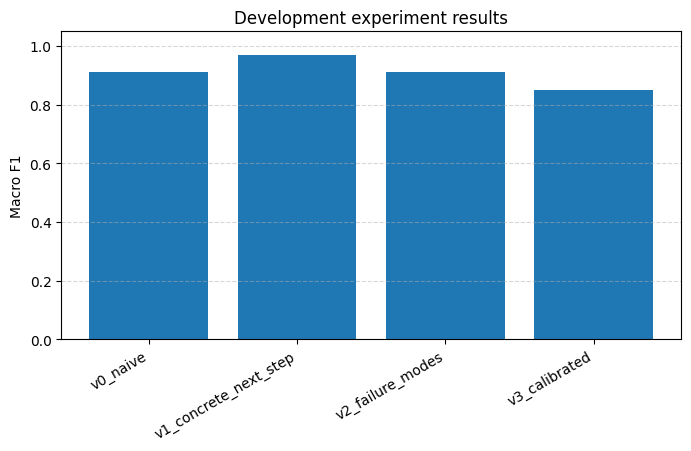

In [20]:
dev_results = experiment_runs[experiment_runs["dataset_split"] == "dev"].copy()

if plt is None:
    dev_results[["judge_version", "accuracy", "macro_f1", "false_good", "false_bad"]]
else:
    plt.figure(figsize=(8, 4))
    plt.bar(dev_results["judge_version"], dev_results["macro_f1"])
    plt.ylabel("Macro F1")
    plt.title("Development experiment results")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1.05)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

## 8. Final Test Run

Now that the prompt has been chosen, we evaluate it once on the held-out test set.

This step should happen after development decisions are done. Otherwise, the test set quietly becomes another development set.

In [21]:
best_dev_run = (
    dev_results
    .sort_values(["macro_f1", "recall_bad", "accuracy"], ascending=False)
    .iloc[0]
)

best_judge_version = best_dev_run["judge_version"]

print("Best development judge:", best_judge_version)
print("Description:", best_dev_run["short_description"])

Best development judge: v1_concrete_next_step
Description: Require a concrete target and next step


In [22]:
test_run, test_predictions = run_experiment(
    examples=test_df,
    judge_version=best_judge_version,
    dataset_split="test",
)

show_run_summary(test_run["experiment_id"])

,experiment_id,judge_version,short_description,provider,model,dataset_split,accuracy,macro_f1,recall_bad,false_good,false_bad
4,v1_concrete_next_step_test_05,v1_concrete_next_step,Require a concrete target and next step,openai,gpt-5.5,test,1.0,1.0,1.0,0,0


In [23]:
print("Test classification report:")
print()
print(classification_report(
    test_predictions["expert_label"],
    test_predictions["predicted_label"],
    labels=LABELS,
    digits=3,
    zero_division=0,
))

Test classification report:

              precision    recall  f1-score   support

         bad      1.000     1.000     1.000         8
        good      1.000     1.000     1.000         7

    accuracy                          1.000        15
   macro avg      1.000     1.000     1.000        15
weighted avg      1.000     1.000     1.000        15



In [24]:
cm = confusion_matrix(
    test_predictions["expert_label"],
    test_predictions["predicted_label"],
    labels=LABELS,
)

cm_df = pd.DataFrame(
    cm,
    index=[f"expert_{label}" for label in LABELS],
    columns=[f"predicted_{label}" for label in LABELS],
)

cm_df

,predicted_bad,predicted_good
expert_bad,8,0
expert_good,0,7


## 9. Final Experiment Log

The final log has one row per run. This makes it easy to compare judge versions, providers, and models without mixing experiment-level metadata with per-example predictions.

In the chart below, development runs are shown together because they are part of prompt iteration. The held-out test run is shown only for the selected judge and highlighted separately, because it answers a different question: how the chosen prompt performs after development is done.

In [25]:
metric_cols = [
    "experiment_id",
    "judge_version",
    "short_description",
    "provider",
    "model",
    "dataset_split",
    "n_examples",
    "accuracy",
    "macro_f1",
    "recall_bad",
    "false_good",
    "false_bad",
]

experiment_runs[metric_cols].sort_values(
    ["dataset_split", "macro_f1"],
    ascending=[True, False],
)

,experiment_id,judge_version,short_description,provider,model,dataset_split,n_examples,accuracy,macro_f1,recall_bad,false_good,false_bad
1,v1_concrete_next_step_dev_02,v1_concrete_next_step,Require a concrete target and next step,openai,gpt-5.5,dev,35,0.971,0.971,0.947,1,0
0,v0_naive_dev_01,v0_naive,Naive binary actionability check,openai,gpt-5.5,dev,35,0.914,0.913,0.947,1,2
2,v2_failure_modes_dev_03,v2_failure_modes,Add explicit bad-review failure modes,openai,gpt-5.5,dev,35,0.914,0.913,0.947,1,2
3,v3_calibrated_dev_04,v3_calibrated,Calibrated rubric using expert comments,openai,gpt-5.5,dev,35,0.857,0.849,1.000,0,5
4,v1_concrete_next_step_test_05,v1_concrete_next_step,Require a concrete target and next step,openai,gpt-5.5,test,15,1.000,1.000,1.000,0,0


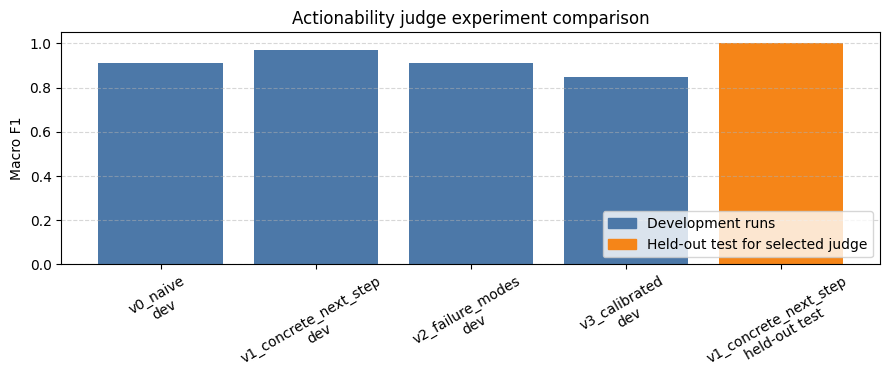

In [26]:
plot_df = experiment_runs.copy()
plot_df["run_label"] = plot_df["judge_version"]
plot_df.loc[plot_df["dataset_split"] == "test", "run_label"] += "\nheld-out test"
plot_df.loc[plot_df["dataset_split"] == "dev", "run_label"] += "\ndev"

split_colors = {
    "dev": "#4C78A8",
    "test": "#F58518",
}
bar_colors = plot_df["dataset_split"].map(split_colors)

if plt is None:
    plot_df[["run_label", "dataset_split", "accuracy", "macro_f1", "false_good", "false_bad"]]
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(plot_df["run_label"], plot_df["macro_f1"], color=bar_colors)
    ax.set_ylabel("Macro F1")
    ax.set_title("Actionability judge experiment comparison")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params(axis="x", rotation=30)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=split_colors["dev"], label="Development runs"),
        plt.Rectangle((0, 0), 1, 1, color=split_colors["test"], label="Held-out test for selected judge"),
    ]
    ax.legend(handles=handles, loc="lower right")

    plt.tight_layout()
    plt.show()

## 10. Save the Selected Judge

The selected judge should be saved as a small, versioned artifact. This makes the judge easier to review, reuse, and compare against future versions.

In [27]:
final_judge = {
    "judge_version": best_judge_version,
    "short_description": JUDGE_CONFIGS[best_judge_version]["short_description"],
    "provider": LIVE_PROVIDER,
    "model": LIVE_MODEL,
    "criteria": JUDGE_CONFIGS[best_judge_version]["criteria"],
}

final_judge

{'judge_version': 'v1_concrete_next_step',
 'short_description': 'Require a concrete target and next step',
 'provider': 'openai',
 'model': 'gpt-5.5',
 'criteria': 'Decide whether the PR review is actionable.\n\nMark the review as good only if it:\n- names a concrete code issue, location, behavior, or improvement area,\n- gives a specific next step, check, or change,\n- uses a constructive and professional tone.\n\nMark the review as bad if it is mostly praise, vague, generic, filler-like, unsupported, or too harsh.'}

In [28]:
# Optional: export the experiment log for later comparison.
# Uncomment when you want to save a local CSV.
# experiment_runs.to_csv("actionability_judge_experiment_runs.csv", index=False)